In [2]:
import numpy as np    
import matplotlib.pyplot as plt
%matplotlib inline    

from RENDES_fizinfo import *

In [ ]:
vez=GPS_to_num_kinem('auto-Posta-Egyetem.csv', orig='first')
vez_sm=num_kinem_smooth_r(vez, 0.1, lam=50, err_report=True)

Adatsor pontosság: RMS=3.854; MAX=5.110
Eltérés          : RMS=1.840; MAX=6.117


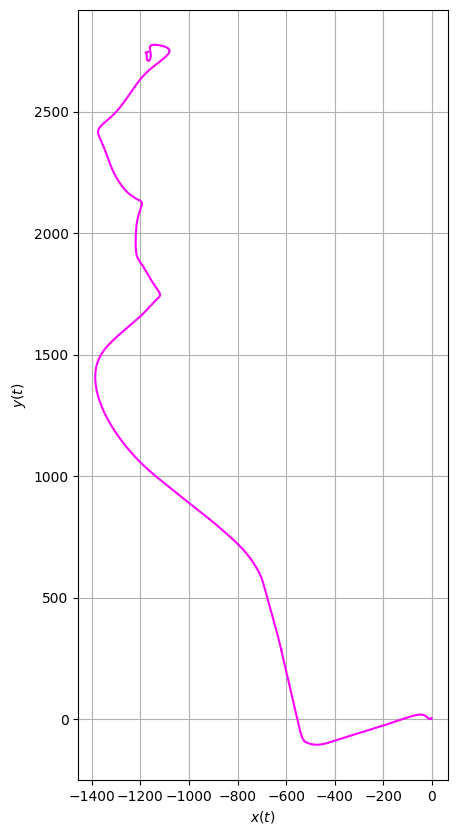

In [5]:
# csak ellenőrzés:

vez_sm.plot_rcomp()

In [8]:
# a) 

In [6]:
vez_sm.v_abs=vect_abs(vez_sm.v)
vez_sm.calc_pathlength

<bound method num_kinem.calc_pathlength of <fizinfo.num_kinem object at 0x000002166D5B35C0>>

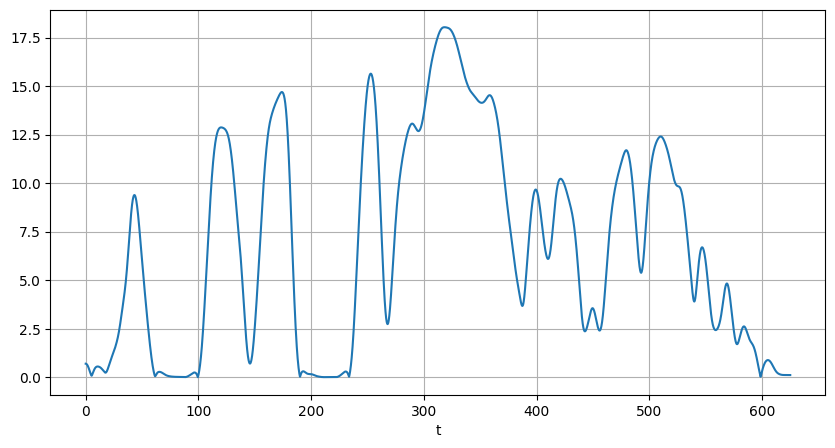

In [7]:
fig=plt.figure(figsize=(10,5))  
ax1=plt.subplot(111)

ax1.plot(vez_sm.t, vez_sm.v_abs)
ax1.set_xlabel('t')

ax1.grid()

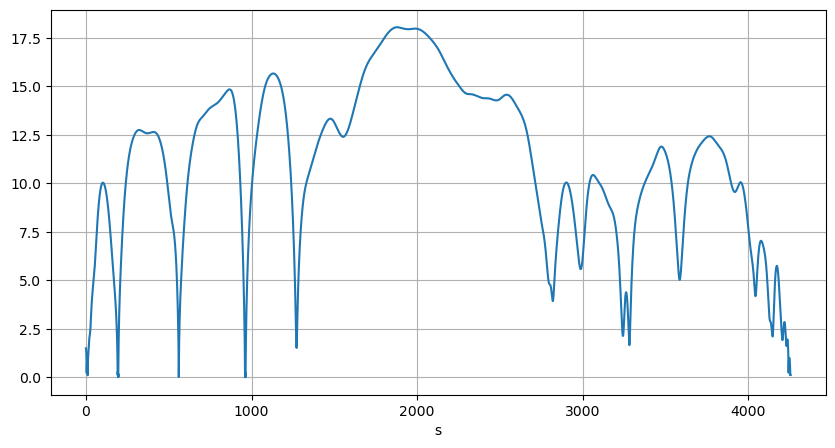

In [12]:
fig=plt.figure(figsize=(10,5))  
ax1=plt.subplot(111)

ax1.plot(vez_sm.pathlength, vez_sm.v_abs)
ax1.set_xlabel('s')

ax1.grid()

In [7]:
# b)

In [13]:
vez_sm.calc_at_acp_Rinv()

In [14]:
map_egyenletes=np.abs(vez_sm.a_t_abs<0.1)

In [17]:
t_egyenletes=integ(vez_sm.t, map_egyenletes*1)[-1] 
t_teljes=vez_sm.t[-1]
print(f"A menetidő {100*t_egyenletes/t_teljes:.2f} %-át töltötte kb. egyenletes haladással.")

A menetidő 65.26 %-át töltötte kb. egyenletes haladással.


In [18]:
s_egyenletes=integ(vez_sm.pathlength, map_egyenletes*1)[-1] 
s_teljes=vez_sm.pathlength[-1]
print(f"Az út {100*s_egyenletes/s_teljes:.2f} %-át töltötte kb. egyenletes haladással.")

Az út 59.96 %-át töltötte kb. egyenletes haladással.


In [10]:
# c)

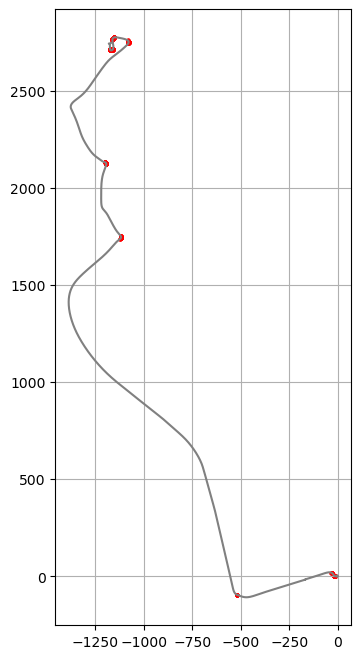

In [19]:
kanyar = (vez_sm.v_abs>2.0) & (vez_sm.Rinv>1/20)

fig=plt.figure(figsize=(8,8))  
ax1=plt.subplot(111)

ax1.plot(vez_sm.r[:,0], vez_sm.r[:,1], color="grey")  # a pályagörbe
ax1.scatter(vez_sm.r[kanyar,0], vez_sm.r[kanyar,1], color="red", s=4)  
ax1.set_aspect(aspect='equal')
ax1.grid()

In [12]:
# d)

In [24]:
dt_work=vez_sm.t[1:]-vez_sm.t[:-1]
ds_work=vez_sm.pathlength[1:]-vez_sm.pathlength[:-1]
vabs_work=vez_sm.v_abs[:-1]
# most korrigáljuk a sebességet:
vabs_korr=np.maximum(vabs_work, 10/3.6)
# korrigáljuk a menetidőt:
dt_korr=dt_work*vabs_work/vabs_korr

print("Menetidő:")
print(f"  -eredeti   : {dt_work.sum():.1f} s")
print(f"  -v>10 km/h : {dt_korr.sum():.1f} s")

Menetidő:
  -eredeti   : 624.9 s
  -v>10 km/h : 470.9 s
